<a href="https://colab.research.google.com/github/BlackBossX/Brain-Tumor-Classification/blob/main/notebooks/BrainTumorClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Brain Tumor Classification

Multi-class classification of brain tumors (Glioma / Meningioma / Pituitary) using a Feed-Forward Neural Network (MLP).



## 1 · Setup — Imports & Drive Mount

In [58]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
import pandas as pd
import numpy as np

#ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


import matplotlib.pyplot as plt
import seaborn as sns

# Model Saving
import joblib


print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", __import__("sklearn").__version__)
print("TensorFlow:", tf.__version__)
print("Matplotlib:", plt.matplotlib.__version__)
print("Seaborn:", sns.__version__)

Pandas: 2.2.2
NumPy: 2.0.2
Scikit-learn: 1.6.1
TensorFlow: 2.20.0
Matplotlib: 3.10.0
Seaborn: 0.13.2




## 2 · Data Loading

In [60]:
df = pd.read_csv("/content/drive/MyDrive/BrainTumorClassification/brain_tumor_data.csv");

In [61]:
df.head()

,patient_id,age,gender,ethnicity,region,bmi,smoking_status,alcohol_consumption,family_history,tumor_size_mm,tumor_location,tumor_growth_rate,headache_severity,nausea,vision_problems,seizures,memory_loss,balance_issues,mri_intensity,ct_density,edema_grade,contrast_enhancement,ki67_index,bp_systolic,bp_diastolic,wbc_count,crp_level,genetic_marker_status,tumor_type
0,PT100001,60,Male,African,Rural,28.1,Never,Moderate,No,13.0,Cerebellum,NaN,4.0,No,Yes,No,No,Yes,164.3,51.4,0.0,Mild,0.7,103,85.0,7.56,7.81,Positive,Meningioma
1,PT100002,50,Male,Asian,Urban,25.0,Never,Moderate,No,14.5,Sellar,4.11,3.0,No,Yes,No,No,No,187.2,35.2,0.0,NaN,NaN,134,97.0,9.17,4.37,Positive,Pituitary
2,PT100003,74,Female,Other,Suburban,21.0,Never,NaN,No,10.7,Temporal,2.36,2.0,No,No,Yes,No,Yes,NaN,43.0,1.0,Strong,3.4,127,62.0,3.67,10.16,Inconclusive,Meningioma
3,PT100004,34,Male,Hispanic,Suburban,29.2,Never,NaN,No,36.7,Occipital,8.34,2.0,No,No,Yes,Yes,Yes,184.0,18.5,3.0,Mild,5.6,100,80.0,7.55,1.70,Positive,Glioma
4,PT100005,59,Male,Asian,Rural,28.2,Former,Moderate,No,16.0,Sellar,3.28,1.0,No,Yes,No,No,No,176.4,24.0,1.0,Moderate,1.4,132,77.0,9.35,8.14,?,Pituitary


In [62]:
df.shape
#df.dtypes

(9000, 29)

In [63]:
df.isna().sum()

,0
patient_id,0
age,0
gender,0
ethnicity,281
region,0
bmi,436
smoking_status,381
alcohol_consumption,3804
family_history,356
tumor_size_mm,0




## 3 · Data Cleaning

### 3.1 · Drop Irrelevant Columns

In [64]:
#remove patient_id column cz not necessary for our predictions
df = df.drop("patient_id",axis=1)

In [65]:
df.head()

,age,gender,ethnicity,region,bmi,smoking_status,alcohol_consumption,family_history,tumor_size_mm,tumor_location,tumor_growth_rate,headache_severity,nausea,vision_problems,seizures,memory_loss,balance_issues,mri_intensity,ct_density,edema_grade,contrast_enhancement,ki67_index,bp_systolic,bp_diastolic,wbc_count,crp_level,genetic_marker_status,tumor_type
0,60,Male,African,Rural,28.1,Never,Moderate,No,13.0,Cerebellum,NaN,4.0,No,Yes,No,No,Yes,164.3,51.4,0.0,Mild,0.7,103,85.0,7.56,7.81,Positive,Meningioma
1,50,Male,Asian,Urban,25.0,Never,Moderate,No,14.5,Sellar,4.11,3.0,No,Yes,No,No,No,187.2,35.2,0.0,NaN,NaN,134,97.0,9.17,4.37,Positive,Pituitary
2,74,Female,Other,Suburban,21.0,Never,NaN,No,10.7,Temporal,2.36,2.0,No,No,Yes,No,Yes,NaN,43.0,1.0,Strong,3.4,127,62.0,3.67,10.16,Inconclusive,Meningioma
3,34,Male,Hispanic,Suburban,29.2,Never,NaN,No,36.7,Occipital,8.34,2.0,No,No,Yes,Yes,Yes,184.0,18.5,3.0,Mild,5.6,100,80.0,7.55,1.70,Positive,Glioma
4,59,Male,Asian,Rural,28.2,Former,Moderate,No,16.0,Sellar,3.28,1.0,No,Yes,No,No,No,176.4,24.0,1.0,Moderate,1.4,132,77.0,9.35,8.14,?,Pituitary


### 3.2 · Normalize Inconsistent Categorical Markers

Replace `'Unknown'` and `'?'` strings with `NaN` so the imputer handles them uniformly.

In [66]:
df['alcohol_consumption'] = df['alcohol_consumption'].replace('Unknown', np.nan)
df['genetic_marker_status'] = df['genetic_marker_status'].replace('?', np.nan)


In [67]:
df["gender"] = df["gender"].str.strip().str.title()

### 3.3 · Verify Missing Values After Cleaning

In [68]:
df.isna().sum()

,0
age,0
gender,0
ethnicity,281
region,0
bmi,436
smoking_status,381
alcohol_consumption,4185
family_history,356
tumor_size_mm,0
tumor_location,0


In [69]:
df.dtypes

,0
age,int64
gender,object
ethnicity,object
region,object
bmi,float64
smoking_status,object
alcohol_consumption,object
family_history,object
tumor_size_mm,float64
tumor_location,object




## 4 · Train / Validation / Test Split


In [70]:
x = df.drop(columns='tumor_type')
y = df['tumor_type']


In [71]:
df['tumor_type'].value_counts()

,count
tumor_type,
Glioma,3802
Meningioma,3089
Pituitary,2109


In [72]:
X_train , X_temp , Y_train , Y_temp = train_test_split(
    x,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
    )

In [73]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=42,
    stratify=Y_temp
)

In [74]:
print(Y_train.value_counts(normalize=True) * 100)
print(y_val.value_counts(normalize=True) * 100)
print(y_test.value_counts(normalize=True) * 100)


tumor_type
Glioma        42.253968
Meningioma    34.317460
Pituitary     23.428571
Name: proportion, dtype: float64
tumor_type
Glioma        42.222222
Meningioma    34.296296
Pituitary     23.481481
Name: proportion, dtype: float64
tumor_type
Glioma        42.222222
Meningioma    34.370370
Pituitary     23.407407
Name: proportion, dtype: float64




## 5 · Preprocessing Pipeline

### 5.1 · Identify Feature Types

In [75]:
numeric_cols = X_train.select_dtypes(include='number').columns
categorical_cols = X_train.select_dtypes(exclude='number').columns

In [76]:
numeric_cols

Index(['age', 'bmi', 'tumor_size_mm', 'tumor_growth_rate', 'headache_severity',
       'mri_intensity', 'ct_density', 'edema_grade', 'ki67_index',
       'bp_systolic', 'bp_diastolic', 'wbc_count', 'crp_level'],
      dtype='object')

In [77]:
categorical_cols

Index(['gender', 'ethnicity', 'region', 'smoking_status',
       'alcohol_consumption', 'family_history', 'tumor_location', 'nausea',
       'vision_problems', 'seizures', 'memory_loss', 'balance_issues',
       'contrast_enhancement', 'genetic_marker_status'],
      dtype='object')

### 5.2 · Missing Value Imputation

- **Numeric** → median (robust to outliers)
- **Categorical** → most frequent (mode)

In [78]:
numeric_imputer = SimpleImputer(strategy='median')
categorical_imputer = SimpleImputer(strategy='most_frequent')

In [79]:
numeric_imputer.fit(X_train[numeric_cols])
categorical_imputer.fit(X_train[categorical_cols])

SimpleImputer(strategy='most_frequent')

In [80]:
X_train[numeric_cols] = numeric_imputer.transform(X_train[numeric_cols])
X_val[numeric_cols] = numeric_imputer.transform(X_val[numeric_cols])
X_test[numeric_cols] = numeric_imputer.transform(X_test[numeric_cols])

X_train[categorical_cols] = categorical_imputer.transform(X_train[categorical_cols])
X_val[categorical_cols] = categorical_imputer.transform(X_val[categorical_cols])
X_test[categorical_cols] = categorical_imputer.transform(X_test[categorical_cols])

### 5.3 · Inspect Unique Values (Pre-Encoding)

In [81]:
for col in categorical_cols:
    print("=" * 40)
    print(col)
    print(X_test[col].unique())

gender
['Male' 'Female']
ethnicity
['Asian' 'Hispanic' 'Caucasian' 'African' 'Other']
region
['Urban' 'Suburban' 'Rural']
smoking_status
['Former' 'Never' 'Current']
alcohol_consumption
['Heavy' 'Moderate']
family_history
['No' 'Yes']
tumor_location
['Frontal' 'Parietal' 'Temporal' 'Sellar' 'Occipital' 'Convexity'
 'Cerebellum']
nausea
['Yes' 'No']
vision_problems
['Yes' 'No']
seizures
['Yes' 'No']
memory_loss
['No' 'Yes']
balance_issues
['No' 'Yes']
contrast_enhancement
['Moderate' 'Strong' 'Mild']
genetic_marker_status
['Negative' 'Positive' 'Inconclusive']


### 5.4 · Categorical Encoding

| Strategy | Applied To |
|---|---|
| Binary mapping | `gender`, `nausea`, `vision_problems`, `seizures`, `memory_loss`, `balance_issues`, `family_history`, `alcohol_consumption`, |
| Ordinal mapping | `headache_severity`, `edema_grade`,`contrast_enhancement`  |
| One-Hot Encoding | `genetic_marker_status`, `tumor_location`, `smoking_status`, `region`, `ethnicity` |

In [82]:
#Binary Mapping
mapping = {"Male": 0, "Female": 1}

for dataset in [X_train, X_val, X_test]:
    dataset["gender"] = dataset["gender"].map(mapping)

In [83]:
#Binary Mapping
mapping = {"Yes": 1, "No": 0}

for dataset in [X_train, X_val, X_test]:
    dataset["nausea"] = dataset["nausea"].map(mapping)
    dataset["vision_problems"] = dataset["vision_problems"].map(mapping)
    dataset["seizures"] = dataset["seizures"].map(mapping)
    dataset["memory_loss"] = dataset["memory_loss"].map(mapping)
    dataset["balance_issues"] = dataset["balance_issues"].map(mapping)
    dataset["family_history"] = dataset["family_history"].map(mapping)

In [84]:
#Binary Mapping
mapping = {"Moderate": 0, "Heavy": 1}

for dataset in [X_train, X_val, X_test]:
    dataset["alcohol_consumption"] = dataset["alcohol_consumption"].map(mapping)

In [85]:
#Ordinal Encoding
mapping = {
    "Mild": 0,
    "Moderate": 1,
    "Strong": 2
}

for dataset in [X_train, X_val, X_test]:
    dataset["contrast_enhancement"] = dataset["contrast_enhancement"].map(mapping)

In [86]:
#One hot
one_hot_cols = [
    "genetic_marker_status",
    "tumor_location",
    "smoking_status",
    "region",
    "ethnicity"
]

onehot = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

train_encoded = onehot.fit_transform(X_train[one_hot_cols])
val_encoded = onehot.transform(X_val[one_hot_cols])
test_encoded = onehot.transform(X_test[one_hot_cols])


In [87]:
encoded_columns = onehot.get_feature_names_out(one_hot_cols)

train_encoded = pd.DataFrame(
    train_encoded,
    columns=encoded_columns,
    index=X_train.index
)

val_encoded = pd.DataFrame(
    val_encoded,
    columns=encoded_columns,
    index=X_val.index
)

test_encoded = pd.DataFrame(
    test_encoded,
    columns=encoded_columns,
    index=X_test.index
)

In [88]:
X_train = X_train.drop(columns=one_hot_cols)
X_val = X_val.drop(columns=one_hot_cols)
X_test = X_test.drop(columns=one_hot_cols)

X_train = pd.concat([X_train, train_encoded], axis=1)
X_val = pd.concat([X_val, val_encoded], axis=1)
X_test = pd.concat([X_test, test_encoded], axis=1)

#### Verify Encoded Features

In [89]:
for col in X_test.columns:
    if X_test[col].nunique() <= 10:
        print("=" * 40)
        print(col)
        print(X_test[col].unique())

gender
[0 1]
alcohol_consumption
[1 0]
family_history
[0 1]
nausea
[1 0]
vision_problems
[1 0]
seizures
[1 0]
memory_loss
[0 1]
balance_issues
[0 1]
edema_grade
[0. 1. 2. 3.]
contrast_enhancement
[1 2 0]
genetic_marker_status_Inconclusive
[0. 1.]
genetic_marker_status_Negative
[1. 0.]
genetic_marker_status_Positive
[0. 1.]
tumor_location_Cerebellum
[0. 1.]
tumor_location_Convexity
[0. 1.]
tumor_location_Frontal
[1. 0.]
tumor_location_Occipital
[0. 1.]
tumor_location_Parietal
[0. 1.]
tumor_location_Sellar
[0. 1.]
tumor_location_Temporal
[0. 1.]
smoking_status_Current
[0. 1.]
smoking_status_Former
[1. 0.]
smoking_status_Never
[0. 1.]
region_Rural
[0. 1.]
region_Suburban
[0. 1.]
region_Urban
[1. 0.]
ethnicity_African
[0. 1.]
ethnicity_Asian
[1. 0.]
ethnicity_Caucasian
[0. 1.]
ethnicity_Hispanic
[0. 1.]
ethnicity_Other
[0. 1.]


In [90]:
X_train

,age,gender,bmi,alcohol_consumption,family_history,tumor_size_mm,tumor_growth_rate,headache_severity,nausea,vision_problems,seizures,memory_loss,balance_issues,mri_intensity,ct_density,edema_grade,contrast_enhancement,ki67_index,bp_systolic,bp_diastolic,wbc_count,crp_level,genetic_marker_status_Inconclusive,genetic_marker_status_Negative,genetic_marker_status_Positive,tumor_location_Cerebellum,tumor_location_Convexity,tumor_location_Frontal,tumor_location_Occipital,tumor_location_Parietal,tumor_location_Sellar,tumor_location_Temporal,smoking_status_Current,smoking_status_Former,smoking_status_Never,region_Rural,region_Suburban,region_Urban,ethnicity_African,ethnicity_Asian,ethnicity_Caucasian,ethnicity_Hispanic,ethnicity_Other
8919,52.0,0,20.6,0,0,47.7,4.08,6.0,0,0,1,0,0,116.1,52.0,1.0,2,8.1,129.0,91.0,5.37,20.29,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
7590,39.0,1,30.1,0,0,64.9,9.58,5.0,1,0,1,0,1,234.6,70.3,1.0,2,15.2,160.0,67.0,4.97,8.33,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5457,29.0,0,24.0,0,0,11.8,2.68,5.0,1,1,0,0,0,163.3,76.3,0.0,0,0.8,136.0,73.0,7.67,2.86,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
8223,38.0,0,25.8,1,0,23.0,11.46,8.0,0,0,0,0,0,199.3,32.5,3.0,2,15.5,124.0,98.0,10.86,3.93,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7068,30.0,0,26.1,0,0,39.2,8.58,5.0,1,0,1,0,0,165.9,45.5,0.0,0,12.8,87.0,98.0,9.18,2.02,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4439,42.0,1,38.3,0,0,14.4,1.81,0.0,0,1,0,0,0,143.9,59.3,0.0,0,4.9,148.0,68.0,3.69,11.05,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
7172,48.0,1,20.6,0,0,31.7,5.47,0.0,0,0,0,0,1,163.8,44.5,2.0,1,27.6,137.0,88.0,5.70,4.00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1119,66.0,1,26.7,0,0,22.2,4.29,7.0,0,0,1,0,1,124.1,47.6,2.0,2,1.1,108.0,86.0,6.09,6.62,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1031,45.0,1,28.6,0,0,48.1,4.09,6.0,1,0,0,0,0,162.5,42.0,0.0,1,0.9,131.0,93.0,9.25,1.74,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### 5.5 · Standard Scaling


In [91]:
for col in numeric_cols:
    print(f"{col}: {X_train[col].min()} --> {X_train[col].max()}")

age: 5.0 --> 95.0
bmi: 14.0 --> 42.2
tumor_size_mm: 2.0 --> 90.0
tumor_growth_rate: 0.1 --> 19.42
headache_severity: 0.0 --> 10.0
mri_intensity: 37.5 --> 255.0
ct_density: -48.7 --> 113.6
edema_grade: 0.0 --> 3.0
ki67_index: 0.1 --> 60.0
bp_systolic: 85.0 --> 192.0
bp_diastolic: 50.0 --> 121.0
wbc_count: 2.0 --> 15.72
crp_level: 0.1 --> 30.95


In [92]:
numeric_cols = [
    "age",
    "bmi",
    "tumor_size_mm",
    "tumor_growth_rate",
    "headache_severity",
    "mri_intensity",
    "ct_density",
    "ki67_index",
    "bp_systolic",
    "bp_diastolic",
    "wbc_count",
    "crp_level"
]

In [93]:
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [94]:
for col in numeric_cols:
    print(f"{col}: {X_train[col].min()} --> {X_train[col].max()}")

age: -3.444050466279689 --> 2.673364119394537
bmi: -2.7343298368312867 --> 3.7198941222077213
tumor_size_mm: -1.6694796973929507 --> 3.4028493313673156
tumor_growth_rate: -1.3999173087975012 --> 4.004235232096129
headache_severity: -2.094643260749493 --> 2.0914538534244076
mri_intensity: -3.4250192613412054 --> 2.6394115800024776
ct_density: -5.056214927172241 --> 4.19775489388422
ki67_index: -1.0314028234433201 --> 6.418905231784173
bp_systolic: -2.6630255126153215 --> 3.9657995931012113
bp_diastolic: -2.9585478432325996 --> 3.621854781641554
wbc_count: -2.5471691276492114 --> 3.748411975737192
crp_level: -1.4197610692465699 --> 7.588445191285114


In [95]:
pd.set_option("display.max_columns", None)

X_train.head()

,age,gender,bmi,alcohol_consumption,family_history,tumor_size_mm,tumor_growth_rate,headache_severity,nausea,vision_problems,seizures,memory_loss,balance_issues,mri_intensity,ct_density,edema_grade,contrast_enhancement,ki67_index,bp_systolic,bp_diastolic,wbc_count,crp_level,genetic_marker_status_Inconclusive,genetic_marker_status_Negative,genetic_marker_status_Positive,tumor_location_Cerebellum,tumor_location_Convexity,tumor_location_Frontal,tumor_location_Occipital,tumor_location_Parietal,tumor_location_Sellar,tumor_location_Temporal,smoking_status_Current,smoking_status_Former,smoking_status_Never,region_Rural,region_Suburban,region_Urban,ethnicity_African,ethnicity_Asian,ethnicity_Caucasian,ethnicity_Hispanic,ethnicity_Other
8919,-0.249401,0,-1.223767,0,0,0.964673,-0.286640,0.417015,0,0,1,0,0,-1.233459,0.685466,1.0,2,-0.036370,0.062846,0.841403,-1.000806,4.475723,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
7590,-1.133027,1,0.950529,0,0,1.956083,1.251810,-0.001595,1,0,1,0,1,2.070610,1.728889,1.0,2,0.846722,1.983347,-1.382958,-1.184350,0.983401,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5457,-1.812740,0,-0.445598,0,0,-1.104607,-0.678245,-0.001595,1,1,0,0,0,0.082592,2.070995,0.0,0,-0.944337,0.496508,-0.826868,0.054576,-0.613841,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
8223,-1.200998,0,-0.033626,1,0,-0.459038,1.777680,1.254234,0,0,0,0,0,1.086360,-0.426379,3.0,2,0.884035,-0.246912,1.490175,1.518345,-0.301400,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7068,-1.744769,0,0.035036,0,0,0.474732,0.972092,-0.001595,1,0,1,0,0,0.155086,0.314851,0.0,0,0.548212,-2.539122,1.490175,0.747457,-0.859121,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [96]:
X_train.shape

(6300, 43)

---

## 6 · Label Encoding (Target Variable)

Encode `tumor_type` string labels to integers for Keras.

In [97]:
label_encoder = LabelEncoder()

Y_train = label_encoder.fit_transform(Y_train)

y_val = label_encoder.transform(y_val)
y_test = label_encoder.transform(y_test)


In [98]:
Y_train

array([0, 0, 2, ..., 1, 1, 0])

In [99]:
for i, label in enumerate(label_encoder.classes_):
    print(f"{label} -> {i}")

Glioma -> 0
Meningioma -> 1
Pituitary -> 2


---

## 7 · Model Architecture

A 2-hidden-layer MLP with ReLU activations and a 3-class Softmax output.

In [100]:
#no of features
input_dim = X_train.shape[1]
print(input_dim)

43


In [101]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(input_dim,)),
    Dense(32, activation="relu"),
    Dense(3, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [102]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [103]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,995 (19.51 KB)

 Trainable params: 4,995 (19.51 KB)

 Non-trainable params: 0 (0.00 B)

---

## 8 · Model Training

50 epochs, batch size 32, Adam optimizer, sparse categorical crossentropy loss.

In [104]:
history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8590 - loss: 0.3878 - val_accuracy: 0.9533 - val_loss: 0.1377
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9565 - loss: 0.1212 - val_accuracy: 0.9556 - val_loss: 0.1208
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9587 - loss: 0.1103 - val_accuracy: 0.9570 - val_loss: 0.1205
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9608 - loss: 0.1041 - val_accuracy: 0.9519 - val_loss: 0.1326
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9648 - loss: 0.0997 - val_accuracy: 0.9570 - val_loss: 0.1277
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9667 - loss: 0.0959 - val_accuracy: 0.9585 - val_loss: 0.1226
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9668 - loss: 0.0921 - val_accuracy: 0.9563 - val_loss: 0.1290
Epoch 8/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9689 - loss: 0.0883 - val_accuracy: 0.

In [105]:
print("Final Training Accuracy:", history.history["accuracy"][-1])
print("Final Validation Accuracy:", history.history["val_accuracy"][-1])

print("Final Training Loss:", history.history["loss"][-1])
print("Final Validation Loss:", history.history["val_loss"][-1])

Final Training Accuracy: 1.0
Final Validation Accuracy: 0.9385185241699219
Final Training Loss: 0.0010403506457805634
Final Validation Loss: 0.4527052640914917


---

## 9 · Evaluation

### 9.1 · Test Set Performance

In [106]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9459 - loss: 0.3896 
Test Accuracy: 0.9459259510040283
Test Loss: 0.38963454961776733


### 9.2 · Training & Validation Curves

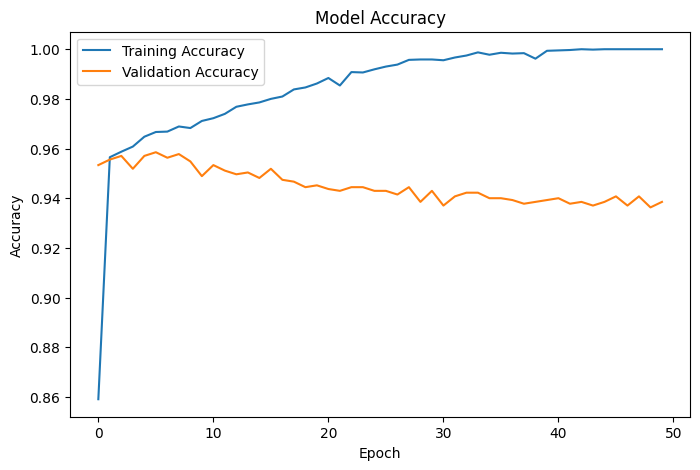

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()

plt.show()

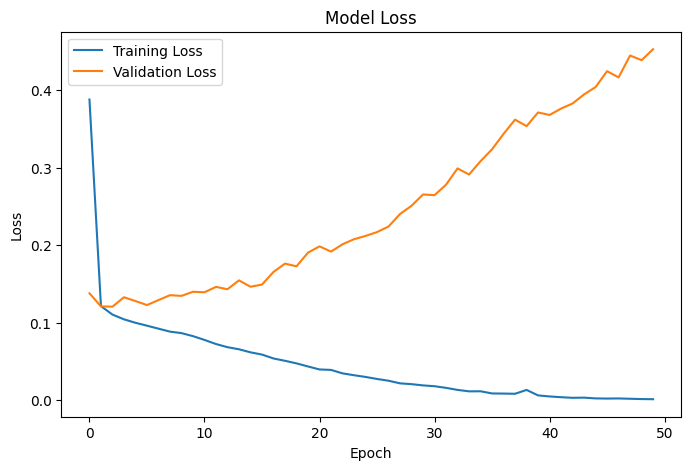

In [108]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()

plt.show()

### 9.3 · Predictions & Classification Report

In [109]:
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

print(classification_report(y_test, predicted_classes))

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       570
           1       0.91      0.94      0.93       464
           2       0.93      0.91      0.92       316

    accuracy                           0.95      1350
   macro avg       0.94      0.94      0.94      1350
weighted avg       0.95      0.95      0.95      1350



### 9.4 · Confusion Matrix

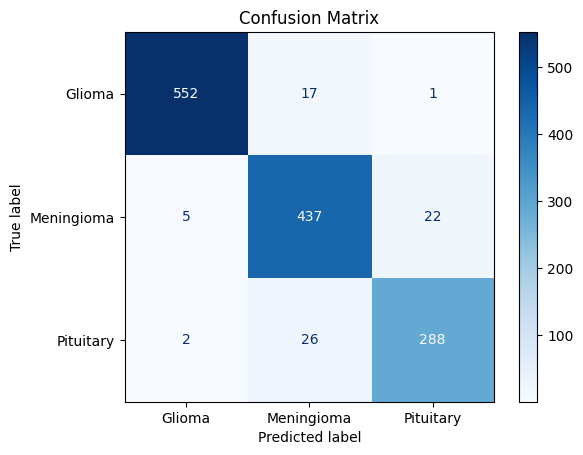

In [110]:

cm = confusion_matrix(y_test, predicted_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Glioma", "Meningioma", "Pituitary"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

---

## 9 · Save Artifacts

Persist all fitted preprocessing objects and the trained model so that `predict.py` can load them for inference on unseen data without re-running training.

| Artifact | File | Purpose |
|---|---|---|
| Keras model | `brain_tumor_model.h5` | Weights & architecture |
| Numeric imputer | `numeric_imputer.pkl` | Median fill for 13 numeric columns |
| Categorical imputer | `categorical_imputer.pkl` | Mode fill for categorical columns |
| OneHot encoder | `onehot_encoder.pkl` | OHE for 5 nominal columns |
| Standard scaler | `standard_scaler.pkl` | Z-score scaling for 12 numeric columns |
| Label encoder | `label_encoder.pkl` | Tumor type string → int mapping |

In [ ]:
import pathlib

# Resolve save directory: works in Colab and locally
MODELS_DIR = pathlib.Path("/content/drive/MyDrive/Brain Tumor Classification/models")
if not MODELS_DIR.exists():
    # Running locally: save to ../models relative to this notebook
    MODELS_DIR = pathlib.Path("../models")

MODELS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Saving artifacts to: {MODELS_DIR.resolve()}")

In [ ]:
# 9.1 · Save Keras model
model_path = MODELS_DIR / "brain_tumor_model.h5"
model.save(str(model_path))
print(f"✓ Model saved  → {model_path}")

In [ ]:
# 9.2 · Save sklearn preprocessing artifacts
artifacts = {
    "numeric_imputer.pkl":     numeric_imputer,
    "categorical_imputer.pkl": categorical_imputer,
    "onehot_encoder.pkl":      onehot,
    "standard_scaler.pkl":     scaler,
    "label_encoder.pkl":       label_encoder,
}

for filename, artifact in artifacts.items():
    path = MODELS_DIR / filename
    joblib.dump(artifact, path)
    print(f"✓ {filename:35s} → {path}")

In [ ]:
# 9.3 · Verify saved files
print("\nSaved files in models/ directory:")
print("-" * 50)
for f in sorted(MODELS_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:40s}  {size_kb:7.1f} KB")
print("-" * 50)
print("\n✓ All artifacts saved. Run predict.py to classify new data:")
print("  python predict.py <path_to_csv>")